In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("../../data/Clean_BNPParibas_Data.csv")

print(df.shape)
display(df.head())

(911, 10)


,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0
4,6,25,17,53.02,850.81,Two Year,DSL,0,Cash,0


In [13]:
X_cluster = df.drop(
    columns=[
        "customer_id",
        "contract_type"
    ]
)

In [14]:
numeric_features = X_cluster.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_cluster.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'support_tickets', 'churn']

Categorical features:
['internet_service', 'payment_method']


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

dbscan_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_dbscan = dbscan_preprocessor.fit_transform(X_cluster)

print(X_dbscan.shape)

(911, 12)


In [16]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors.fit(X_dbscan)

distances, indices = neighbors.kneighbors(X_dbscan)

k_distances = np.sort(distances[:, -1])

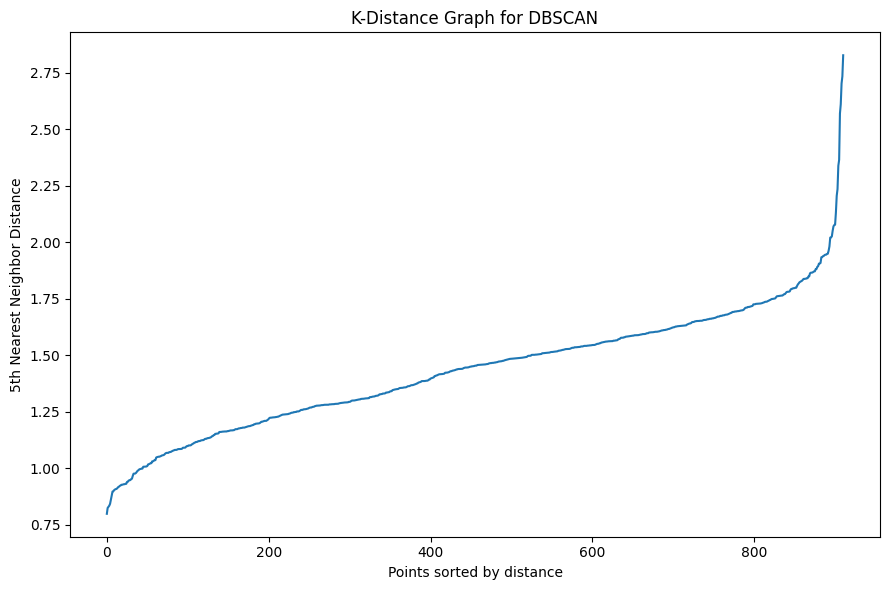

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    k_distances
)

plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")

plt.tight_layout()
plt.show()

In [18]:
eps_values = [
    0.8,
    1.0,
    1.2,
    1.4,
    1.6
]

min_samples_values = [
    3,
    5,
    8,
    10
]

results = []

for eps in eps_values:

    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(
            X_dbscan
        )

        n_clusters = len(
            set(labels) - {-1}
        )

        n_noise = np.sum(
            labels == -1
        )

        if n_clusters > 1:

            score = silhouette_score(
                X_dbscan,
                labels
            )

        else:
            score = np.nan

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

dbscan_results = pd.DataFrame(results)

display(
    dbscan_results.sort_values(
        "silhouette_score",
        ascending=False
    )
)

,eps,min_samples,clusters,noise_points,silhouette_score
17,1.6,5,2,67,0.139325
18,1.6,8,2,172,0.117057
19,1.6,10,2,253,0.098234
16,1.6,3,4,37,0.088338
12,1.4,3,34,129,-0.084067
13,1.4,5,27,279,-0.092206
8,1.2,3,56,264,-0.127292
14,1.4,8,18,537,-0.137115
4,1.0,3,74,523,-0.154443
9,1.2,5,33,511,-0.165571


In [19]:
best_row = dbscan_results.loc[
    dbscan_results["silhouette_score"].idxmax()
]

print(best_row)

optimal_eps = best_row["eps"]
optimal_min_samples = int(
    best_row["min_samples"]
)

eps                  1.600000
min_samples          5.000000
clusters             2.000000
noise_points        67.000000
silhouette_score     0.139325
Name: 17, dtype: float64


In [21]:
dbscan = DBSCAN(
    eps=optimal_eps,
    min_samples=optimal_min_samples
)

dbscan_labels = dbscan.fit_predict(
    X_dbscan
)

In [22]:
dbscan_df = df.copy()

dbscan_df["Cluster"] = dbscan_labels

display(
    dbscan_df.head()
)

,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn,Cluster
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1,-1
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1,0
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0,1
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0,1
4,6,25,17,53.02,850.81,Two Year,DSL,0,Cash,0,1


In [23]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_dbscan
)

In [24]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": dbscan_labels
})

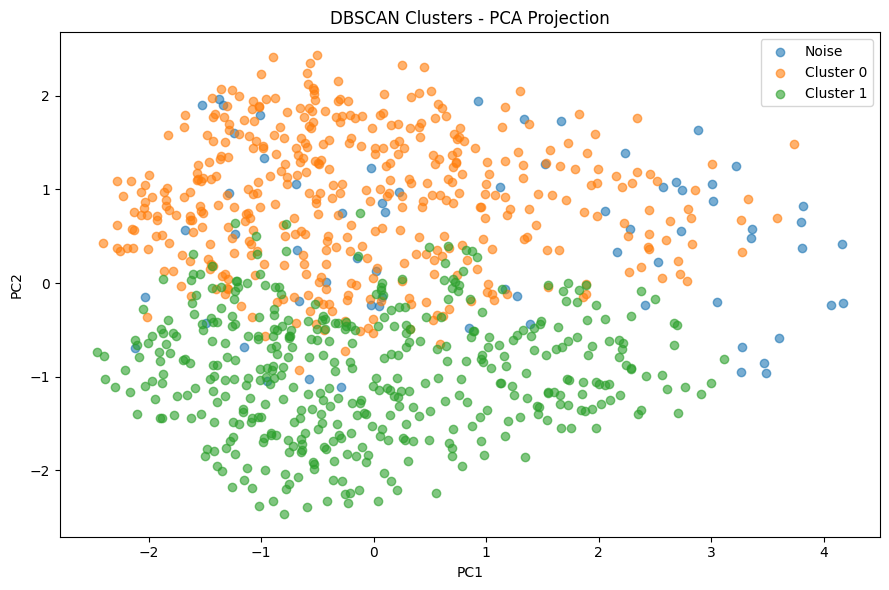

In [25]:
plt.figure(figsize=(9, 6))

for cluster in sorted(
    pca_df["Cluster"].unique()
):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    if cluster == -1:
        label = "Noise"
    else:
        label = f"Cluster {cluster}"

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=label,
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "DBSCAN Clusters - PCA Projection"
)

plt.legend()

plt.tight_layout()
plt.show()